# Blockies Dataset

This notebook is used to generate Concept-based explanations using a concept modeling approach.  

The notebook downloads the modified ResNet model that is trained to predict concepts, instead of the Blocky diagnosis.  A corresponding Explainable Boosting Machine model is downloaded that predicts the diagnosis based on the predicted concepts.  

Using this approach, we can get concept based explanations which can then be used to generate concept-based attribution maps.

In [1]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random
import zipfile

import numpy as np

import pandas as pd

from sklearn.metrics import r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18_regression'

regression_target_columns = [
    'main_spherical', 'sec_spherical', 'bending',  'arm_position',
    'num_sec_bones', 'obj_rotation_roll', 'obj_rotation_pitch', 'obj_rotation_yaw',
    'position_x', 'position_y',
    'obj_color', 'bg_color',
    ]

ds = 'main_blockies/default'

random_state = 42

In [3]:
readable_names = ['Main Bone Shape', 'Sec. Bone Shape', 'Spine Bend', 'Arm Position',
                  'Num. Sec. Bones', 'Position - Roll', 'Position - Pitch', 'Position - Yaw',
                  'Position - X', 'Position-Y', 'Blocky Color', 'Background Color']
name_map = {col: n for col, n in zip(regression_target_columns, readable_names)}
name_map_pred = {f'{col}_pred': n for col, n in zip(regression_target_columns, readable_names)}

# Setup and Load Datasets

In [4]:
# data downloading and dataset utilities

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

class ImageRegressionDataset(Dataset):
    def __init__(self, df, data_dir, transform=None, target_columns=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform
        self.target_columns = target_columns if target_columns is not None else ['main_spherical', 'sec_spherical', 'bending', 'arm_position']


    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        # Load the specified target columns instead of just 'ill'
        targets = self.df.iloc[idx][self.target_columns].values.astype(np.float32)
        targets = torch.tensor(targets)

        if self.transform:
            image = self.transform(image)

        return image, targets

## Load XAI Study Data

In [5]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [6]:
study_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

study_dir = download_file(url=study_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='/content/data', # change this if not using Colab
                          extract=True,
                          force_download=True,
                          archive_folder=zip_name)
study_dir

100%|██████████| 7.81M/7.81M [00:00<00:00, 8.49MB/s]


File downloaded to: /content/data/study_samples.zip
Extracting zip file...
File extracted to: /content/data


PosixPath('/content/data/study_samples')

In [7]:
# load and preprocess study dataframes
main_dir = study_dir / 'main_data/xai_samples'
tutorial_dir = study_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv', dtype={'sec_bones': str})
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})
study_df['num_sec_bones'] = study_df.sec_bones.apply(lambda x: x.count('1'))

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv', dtype={'sec_bones': str})
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})
tutorial_df['num_sec_bones'] = tutorial_df.sec_bones.apply(lambda x: x.count('1'))

In [8]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])


study_dataset = ImageRegressionDataset(study_df, main_dir, transform=transform, target_columns=regression_target_columns)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=6, pin_memory=True)

tutorial_dataset = ImageRegressionDataset(tutorial_df, tutorial_dir, transform=transform, target_columns=regression_target_columns)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=6, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Model Loading and Evaluation





In [9]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

def load_resnet18_regression(num_targets, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_targets)
  print("Loaded ResNet18")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [10]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device, num_targets):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0

    all_preds = []
    all_labels = []


    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            all_preds.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = running_loss / len(dataloader)
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Calculate R-squared for each target
    r2_scores = []
    for i in range(num_targets):
        r2 = r2_score(all_labels[:, i], all_preds[:, i])
        r2_scores.append(r2)

    print(f"Evaluation Loss: {avg_loss:.4f}")
    for i, r2 in enumerate(r2_scores):
        print(f"R-squared for target {i}: {r2:.4f}")
    return all_preds, avg_loss, r2_scores

In [11]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/qpOuSHKCgN31OCO/download',
                                file_name='best_model.pth',
                                cache_dir=f'/content/model/{modeltype}_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=True)
checkpoint_path

100%|██████████| 42.7M/42.7M [00:03<00:00, 13.4MB/s]

File downloaded to: /content/model/resnet18_regression_checkpoint/best_model.pth


PosixPath('/content/model/resnet18_regression_checkpoint/best_model.pth')

In [12]:
# Define loss function and optimizer
criterion = nn.MSELoss(reduction='sum')

n_targets = len(regression_target_columns)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [13]:
# load best model and evaluate
model = load_resnet18_regression(n_targets,
                                 pretrained=False,
                                 checkpoint_path=checkpoint_path)
model.to(device)

study_preds, _, _ = evaluate_model(model, study_dataloader, criterion, device, n_targets)
tutorial_preds, _, _ = evaluate_model(model, tutorial_dataloader, criterion, device, n_targets)

Loaded ResNet18
Loaded checkpoint from: /content/model/resnet18_regression_checkpoint/best_model.pth
Evaluation Loss: 0.3791
R-squared for target 0: 0.9694
R-squared for target 1: 0.8239
R-squared for target 2: 0.7605
R-squared for target 3: 0.5902
R-squared for target 4: 0.7804
R-squared for target 5: 0.1163
R-squared for target 6: 0.9574
R-squared for target 7: 0.9829
R-squared for target 8: 0.7302
R-squared for target 9: 0.8703
R-squared for target 10: 0.9915
R-squared for target 11: 0.9984


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Evaluation Loss: 0.0057
R-squared for target 0: 0.9988
R-squared for target 1: 0.9737
R-squared for target 2: 0.9915
R-squared for target 3: 0.9616
R-squared for target 4: 0.9967
R-squared for target 5: -0.1399
R-squared for target 6: 0.9965
R-squared for target 7: 0.9998
R-squared for target 8: 0.9929
R-squared for target 9: 0.9901
R-squared for target 10: 0.9978
R-squared for target 11: 0.9994


In [14]:
# add concept preds to dataframe
study_preds_df = pd.DataFrame(study_preds, columns=regression_target_columns)
tutorial_preds_df = pd.DataFrame(tutorial_preds, columns=regression_target_columns)

new_cols = [f'{f}_pred' for f in regression_target_columns]

# study_df[new_cols] = study_preds_df
# tutorial_df[new_cols] = tutorial_preds_df

## Load Interpretable Model

In [15]:
%pip install interpret -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 51.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 78.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 103.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 778.9/778.9 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.0/228.0 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.8/259.8 kB 20.3 MB/s eta 0:00:00


In [16]:
import joblib

In [17]:
ebm_model = download_file(url='https://uni-bielefeld.sciebo.de/s/elbFZKs3PlzVxGK/download',
                          file_name='ebm_model.joblib',
                          cache_dir=f'/content/model', # change this if not using Colab
                          extract=False,
                          force_download=True)
ebm_model

100%|██████████| 20.8M/20.8M [00:01<00:00, 16.4MB/s]

File downloaded to: /content/model/ebm_model.joblib


PosixPath('/content/model/ebm_model.joblib')

In [18]:
ebm = joblib.load(ebm_model)

In [19]:
X_study = study_df[new_cols].copy()
X_study = X_study.rename(columns=name_map_pred)

X_tutorial = tutorial_df[new_cols].copy()
X_tutorial = X_tutorial.rename(columns=name_map_pred)

In [20]:
(tutorial_df['concept_pred'] == tutorial_df['ill']).mean()

np.float64(0.6)

In [21]:
study_preds = ebm.predict(X_study)
tutorial_preds = ebm.predict(X_tutorial)

ebm.score(X_study, study_df['ill']), ebm.score(X_tutorial, tutorial_df['ill'])

(0.8, 0.6)

In [22]:
# compare to saved accuracies
(study_df['pred'] == study_df['ill']).mean(), (tutorial_df['pred'] == tutorial_df['ill']).mean()

(np.float64(0.8), np.float64(0.6))

In [23]:
# assert that all predictions are the same
assert (study_preds == study_df['pred']).all(), 'Study predictions are incorrect'
assert (tutorial_preds == tutorial_df['pred']).all(), 'Tutorial predictions are incorrect '

print('All predictions for each dataset are equal. This is the correct model')

All predictions for each dataset are equal. This is the correct model


# View Images

In [24]:
study_img_paths = study_df['filename'].apply(lambda x: os.path.join(main_dir, x)).tolist()
tutorial_img_paths = tutorial_df['filename'].apply(lambda x: os.path.join(tutorial_dir, x)).tolist()

study_imgs = [Image.open(path).convert('RGB') for path in study_img_paths]
tutorial_imgs = [Image.open(path).convert('RGB') for path in tutorial_img_paths]

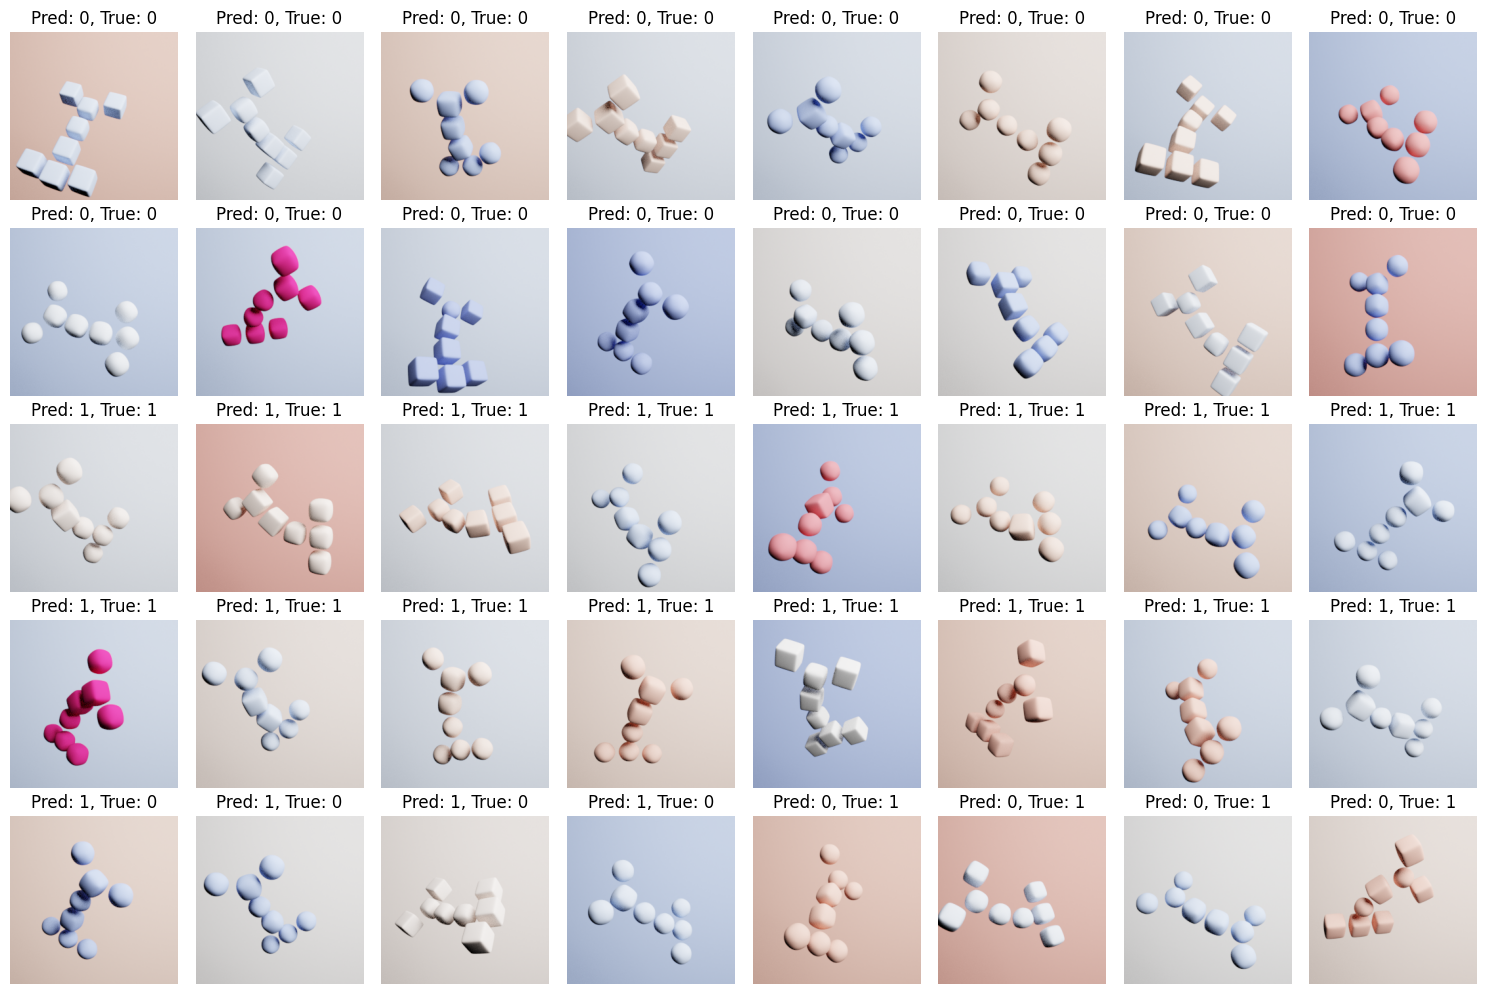

In [25]:
cols = 8
rows = len(study_imgs) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 10))

for i, ax in enumerate(axes.flatten()):
  ax.imshow(study_imgs[i])
  ax.axis('off')
  pred = study_df.iloc[i]['pred']
  true = study_df.iloc[i]['ill']
  ax.set_title(f'Pred: {pred}, True: {true}')

plt.tight_layout()
plt.show()

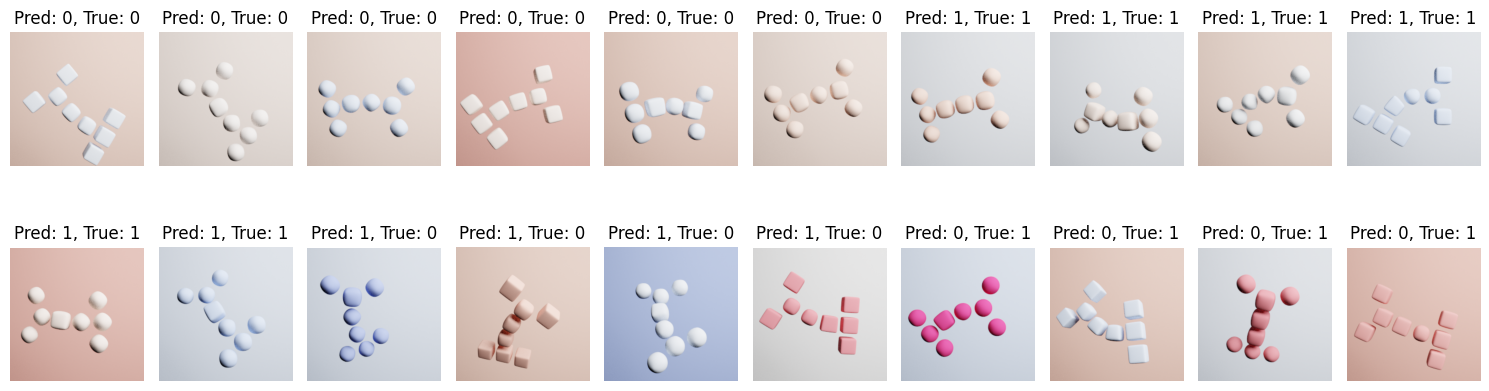

In [26]:
cols = 10
rows = len(tutorial_imgs) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 5))

for i, ax in enumerate(axes.flatten()):
  ax.imshow(tutorial_imgs[i])
  ax.axis('off')
  pred = tutorial_df.iloc[i]['pred']
  true = tutorial_df.iloc[i]['ill']
  ax.set_title(f'Pred: {pred}, True: {true}')

plt.tight_layout()
plt.show()

# Generate Explanations

In [27]:
from interpret import show

In [28]:
# show(ebm.explain_global(), show_instances=True)

In [29]:
exp = ebm.explain_local(X_study, study_df['ill'])

In [30]:
# show(exp)

In [31]:
idx = 17
sorted_indices = np.argsort(abs(np.array(exp.data(idx)['scores'])))
sorted_indices = sorted_indices[::-1]
scores = np.array(exp.data(idx)['scores'])[sorted_indices]
names = np.array(exp.data(idx)['names'])[sorted_indices]

In [32]:
# plt.imshow(study_imgs[idx])
# print(study_df.iloc[idx].ill_chars)

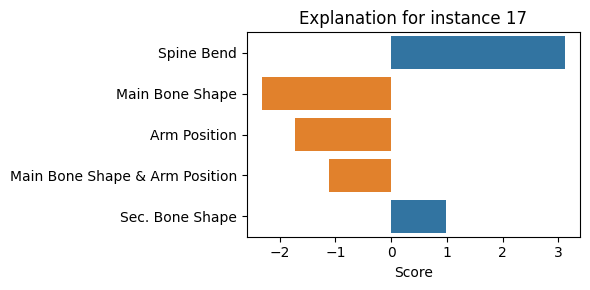

In [33]:
n_features = 5

colors = [sns.color_palette()[1] if s < 0 else sns.color_palette()[0]for s in scores[:n_features]]
plt.figure(figsize=(6, 3))
sns.barplot(x=scores[:n_features], y=names[:n_features], hue=names[:n_features], orient='h', palette=colors)
plt.title(f"Explanation for instance {idx}")
plt.xlabel("Score")
plt.tight_layout()
plt.show()

In [34]:
def process_names(name):
  name = name.split(' & ') if '&' in name else [str(name)]
  return name

In [35]:
feature_idxs = [tuple(readable_names.index(n) for n in process_names(ns)) for ns in names[:n_features]]
feature_idxs

[(2,), (0,), (3,), (0, 3), (1,)]

## Generate LRP / CRP Exps

In [36]:
!uv pip install zennit -q

In [37]:
from zennit.rules import Epsilon
from zennit.image import imgify

from zennit.attribution import Gradient
from zennit.torchvision import ResNetCanonizer
from zennit.canonizers import SequentialMergeBatchNorm
from zennit.composites import EpsilonPlusFlat, EpsilonGammaBox, EpsilonAlpha2Beta1Flat, EpsilonAlpha2Beta1

In [38]:
def multihot_encode(labels, num_classes):
  """
    Generates a multi-hot encoded tensor from a tuple of labels.

    Args:
        labels (tuple): A tuple of integer labels.
        num_classes (int): The total number of possible classes.

    Returns:
        torch.Tensor: A multi-hot encoded tensor of shape (num_classes,).
    """
  one_hot = torch.zeros(num_classes)
  for label in labels:
    one_hot[label] = 1
  return one_hot

In [39]:
targets = []
imgs = []
for idxs in feature_idxs:
  t = multihot_encode(idxs, len(new_cols))
  targets.append(t)
  imgs.append(study_imgs[idx])

targets = torch.stack(targets)
inp = [transform(img) for img in imgs]
inp = torch.stack(inp)
imgs_np = np.array([np.array(img) for img in imgs])

In [40]:
transform_norm = T.Compose([
    T.Normalize(mean=mean, std=std)
])
low, high = transform_norm(torch.tensor([[[[[0.]]] * 3], [[[[1.]]] * 3]]))

with Gradient(model=model, composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attributor:
  inp = inp.to('cpu')
  output, attribution = attributor(inp, targets)

In [41]:
import matplotlib as mpl

def combine_and_save(img, attribution, alpha, filter_perc, filename):

    relevance = attribution.sum(0)

    mask_neg = relevance < 0
    neg_rel = abs(relevance) * mask_neg
    thresh_neg = torch.quantile(neg_rel.flatten(), filter_perc)
    mask_neg = neg_rel > thresh_neg

    mask_pos = relevance > 0
    pos_rel = relevance * mask_pos
    thresh_pos = torch.quantile(pos_rel.flatten(), filter_perc)
    mask_pos = pos_rel > thresh_pos

    relevance = relevance * (mask_neg | mask_pos)

    vmax = relevance.abs().max()
    grayscale_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])

    cmap = plt.get_cmap('seismic')
    norm = mpl.colors.Normalize(vmin=-vmax, vmax=vmax, clip=False)
    heatmap_colored = cmap(norm(relevance))[:, :, :3] # Take only RGB channels

    # Convert grayscale image to RGB
    grayscale_rgb = np.stack([grayscale_img] * 3, axis=-1)

    # Combine the grayscale image and the colored heatmap
    # You can adjust the alpha value for the heatmap overlay
    combined_img_np = (grayscale_rgb * (1 - alpha) + heatmap_colored * 255 * alpha).astype(np.uint8)

    # Convert to PIL Image and save
    combined_img_pil = Image.fromarray(combined_img_np)
    combined_img_pil.save(filename)
    print(f"Combined image saved to {filename}")

    return combined_img_pil

In [42]:
# def plot_lrp(img, attribution, ax, filter_perc=.75):
#   relevance = attribution.sum(0)

#   mask_neg = relevance < 0
#   neg_rel = abs(relevance) * mask_neg
#   thresh_neg = torch.quantile(neg_rel.flatten(), filter_perc)
#   mask_neg = neg_rel > thresh_neg

#   mask_pos = relevance > 0
#   pos_rel = relevance * mask_pos
#   thresh_pos = torch.quantile(pos_rel.flatten(), filter_perc)
#   mask_pos = pos_rel > thresh_pos

#   relevance = relevance * (mask_neg | mask_pos)


#   vmax = relevance.abs().max()
#   grayscale_img = np.dot(img[..., :3], [0.2989, 0.5870, 0.1140])
#   ax.imshow(grayscale_img, cmap='gray', vmin=0, vmax=255)
#   ax.imshow(relevance, cmap='seismic', vmin=-vmax, vmax=vmax, alpha=0.85)

In [43]:
import random, string, ast, csv, shutil, zipfile, io
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import matplotlib.pyplot as plt

# config

OUT_DIR  = Path("/content/explanations_flat")
CSV_PATH = Path("/content/input_concept.csv")
ZIP_PATH = Path("/content/explanations_flat.zip")

N_COMBINED  = 3
ALPHA       = 0.60
FILTER_PERC = 0.90

CLASSES   = ['Healthy', 'OCDegen']
LOCATIONS = ["DEN", "SEA", "CHI", "SF", "MIA", "PHX", "BOS", "ATL"]


# small helpers

def generate_patient_id(length=10):
    return ''.join(random.choices(string.ascii_uppercase + string.digits, k=length))

def get_caption(true_diag, sugg_diag):
    return f"True Diagnosis: {true_diag}\r\nSuggested Diagnosis: {sugg_diag}"

def get_trait(ill_char_string):
    try:
        traits = ast.literal_eval(ill_char_string) if isinstance(ill_char_string, str) else ill_char_string
    except:
        traits = []
    mapped = []
    for t in traits:
        if "mutation_color" in t.lower():
            continue
        if t in ["high_bend", "med_bend"] and "Strong Spine Bend" not in mapped:
            mapped.append("Strong Spine Bend")
        elif t in ["high_sphere_diff", "med_sphere_diff"] and "Strong Bone Variation" not in mapped:
            mapped.append("Strong Bone Variation")
        elif t == "mutation_mainbones" and "Main Bones Mutation" not in mapped:
            mapped.append("Main Bones Mutation")
        elif t == "stretchy" and "Tucked Head" not in mapped:
            mapped.append("Tucked Head")
        else:
            mapped.append(t)
    return ", ".join(mapped) if mapped else "No Trait"


# output folfer

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir()

rows = []

# reverse map unchanged
reverse_name_map = {v: k for k, v in name_map.items()}

for idx in tqdm(range(len(study_imgs)), desc="Writing PNGs"):
    blocky_id = idx + 1
    base_name = f"blocky{blocky_id:02d}"

    # original
    img_pil  = study_imgs[idx]
    orig_fn  = f"{base_name}_original.png"
    img_pil.save(OUT_DIR / orig_fn)

    true_diag  = CLASSES[int(study_df.loc[idx, 'ill'])]
    sugg_diag  = CLASSES[int(study_df.loc[idx, 'pred'])]
    trait_text = get_trait(study_df.loc[idx, 'ill_chars'])

    #  top-3 concepts
    ed        = exp.data(idx)
    scores_all= np.array(ed["scores"])
    names_all = np.array(ed["names"])
    order     = np.argsort(np.abs(scores_all))[::-1][::-1]   # double-flip
    top_names = names_all[order][:N_COMBINED]

    tuples = [tuple(regression_target_columns.index(reverse_name_map[n])
                    for n in (nm.split(' & ') if '&' in nm else [nm]))
              for nm in top_names]

    # model input
    inp     = torch.stack([transform(img_pil)] * N_COMBINED)
    targets = torch.stack([multihot_encode(t, len(regression_target_columns)) for t in tuples])

    with Gradient(model=model,
                  composite=EpsilonAlpha2Beta1Flat(canonizers=[ResNetCanonizer()])) as attr:
        _, hms = attr(inp.to('cpu'), targets)

    raw_np = np.asarray(img_pil)
    example_fns = []
    for j, hm in enumerate(hms, start=1):
        fn = f"{base_name}_combined{j}.png"
        combine_and_save(
            raw_np,
            hm,
            alpha=ALPHA,
            filter_perc=FILTER_PERC,
            filename=OUT_DIR / fn
        )
        example_fns.append(fn)

    # csv row
    rows.append({
        "INDEX":              None,
        "PATIENT_ID":         generate_patient_id(),
        "X_RAY_IMAGE":        orig_fn,
        "X_RAY_TRAIT":        trait_text,
        "TRUE_DIAG":          true_diag,
        "SUGGESTED_DIAG":     sugg_diag,
        "Concept1":           example_fns[0],
        "Concept1_Caption":   "--Caption--",
        "Concept2":           example_fns[1],
        "Concept2_Caption":   "--Caption--",
        "Concept3":           example_fns[2],
        "Concept3_Caption":   "--Caption--",
        "X_RAY_LOCATION":     random.choice(LOCATIONS)
    })

Writing PNGs:   2%|▎         | 1/40 [00:04<03:00,  4.62s/it]

Combined image saved to /content/explanations_flat/blocky01_combined1.png
Combined image saved to /content/explanations_flat/blocky01_combined2.png
Combined image saved to /content/explanations_flat/blocky01_combined3.png


Writing PNGs:   5%|▌         | 2/40 [00:08<02:30,  3.97s/it]

Combined image saved to /content/explanations_flat/blocky02_combined1.png
Combined image saved to /content/explanations_flat/blocky02_combined2.png
Combined image saved to /content/explanations_flat/blocky02_combined3.png


Writing PNGs:   8%|▊         | 3/40 [00:11<02:19,  3.76s/it]

...

Combined image saved to /content/explanations_flat/blocky38_combined1.png
Combined image saved to /content/explanations_flat/blocky38_combined2.png
Combined image saved to /content/explanations_flat/blocky38_combined3.png


Writing PNGs:  98%|█████████▊| 39/40 [03:02<00:04,  4.87s/it]

Combined image saved to /content/explanations_flat/blocky39_combined1.png
Combined image saved to /content/explanations_flat/blocky39_combined2.png
Combined image saved to /content/explanations_flat/blocky39_combined3.png


Writing PNGs: 100%|██████████| 40/40 [03:07<00:00,  4.69s/it]

Combined image saved to /content/explanations_flat/blocky40_combined1.png
Combined image saved to /content/explanations_flat/blocky40_combined2.png
Combined image saved to /content/explanations_flat/blocky40_combined3.png


In [45]:
# csv file

df = pd.DataFrame(rows)
df["INDEX"] = random.sample(range(1, 100 + len(df)), len(df))
final_columns = [
    "INDEX", "PATIENT_ID", "X_RAY_IMAGE", "X_RAY_TRAIT",
    "TRUE_DIAG", "SUGGESTED_DIAG",
    "Concept1", "Concept1_Caption",
    "Concept2", "Concept2_Caption",
    "Concept3", "Concept3_Caption",
    "X_RAY_LOCATION"
]
df = df[final_columns]
df.to_csv(CSV_PATH, index=False, quoting=csv.QUOTE_ALL)
print("CSV saved ➜", CSV_PATH)

# ---------- ZIP ----------
with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in OUT_DIR.iterdir():
        zf.write(p, p.name)
print("Zip saved ➜", ZIP_PATH)


CSV saved ➜ /content/input_concept.csv
Zip saved ➜ /content/explanations_flat.zip
